Basic Convolutional Network 

Train a simple CNN from scratch. 

Example architecture: 

Conv → ReLU → MaxPool 

Conv → ReLU → MaxPool 

Flatten 

Dense 

Softmax 

In [1]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt

2026-03-25 15:18:26.025457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774451906.493443      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774451906.628881      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774451907.556262      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774451907.556317      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774451907.556320      55 computation_placer.cc:177] computation placer alr

In [3]:
# 2. Set Dataset Path
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


In [4]:
# 3. Data Preprocessing (Data augmentation for Training data)

# Data generators (NO validation_split here)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),   # reduced size (faster)
    batch_size=64,           # bigger batch
    class_mode='categorical' # multi-class
)

# Validation data
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='categorical'
)

#Found 11229 images belonging to 6 classes.
#Found 2805 images belonging to 6 classes.

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.


In [5]:
#4. Load Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=64,
    #target_size=(150,150),
    #batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


**We are building a Convolutional Neural Network (CNN) using Keras (inside TensorFlow)**

**Purpose: Image Classification (6 classes)**


In [7]:
#5. Build CNN Model
# Creates a Sequential model 
# Layers are added one after another (linear stack) 

model = models.Sequential()

# Block 1 (Extracts Low-Level Features)

# Conv2D(32, (3,3)) + MaxPooling

# 32 filters → detects: 
    # edges 
    # corners 
    # textures 

# Input shape: (150,150,3)
    # 150×150 image with 3 color channels (RGB)

# MaxPooling: 
    #Reduces image size 
    #Keeps important features 

#model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

# Block 2 (Extracts mid-Level Features)
    # Conv2D(64, (3,3)) + MaxPooling

# 64 filters → learns: 
    # shapes 
    # patterns 
    # object parts 
# Model becomes deeper → learns more complex features


model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3 (Extracts high-Level Features)
# Conv2D(128, (3,3)) + MaxPooling
# 128 filters → detects: 
        #full objects 
        #class-specific patterns 
#Example:
    #Dog face 
    #Mountain shape 

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

#Extra Conv Layer
# Conv2D(128, (3,3)) + MaxPooling
# Improves:
    #Feature richness 
    #Model depth 
# But:Too many layers → risk of overfitting 

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten
# Flatten()
# Converts 2D feature maps → 1D vector
# Required before Dense layer

#Flatten Layer
    #model.add(layers.Flatten())
#Converts:
    #2D feature maps → 1D vector 

#Example:
#(7 × 7 × 128) → 6272 neurons
#Required before Dense layers

model.add(layers.Flatten())

# Fully Connected Layer : Dense Layers (Dense + Dropout)

# Dense(128, activation='relu')
#Learns:
    #Final classification logic 
    #Combines all extracted features 

# Dropout(0.5)
# Dropout:
    # Prevents overfitting
    #Model memorization 
# Randomly removes/drops 50% neurons during training

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer (6 classes)
# Dense(6, activation='softmax')
    #6 neurons → 6 classes 
    #Softmax → gives probabilities distribution

#Example output:
    #[0.1, 0.7, 0.05, 0.05, 0.05, 0.05]
    #Class 2 predicted (highest probability)


model.add(layers.Dense(6, activation='softmax'))

# Activation Function (Important) ReLU:
# activation='relu'
    #Removes negative values 
    #Speeds up training 
    #Most commonly used in CNNs

#Image → Conv → Pool → Conv → Pool → Conv → Pool
#      → Flatten → Dense → Dropout → Output


This CNN model extracts hierarchical features from images using convolution and pooling layers, 

converts them into a feature vector using flattening, 

and performs classification using dense layers with dropout to prevent overfitting, 

producing final predictions using softmax for 6 classes


•	Early layers → general features (edges) 

•	Deep layers → specific features (objects) 

•	Dropout → improves generalization 

•	Increasing filters → increases learning capacity 



In [8]:
#6. Compile Model
model.compile(
    optimizer='adam', #faster than RMSprop
    loss='categorical_crossentropy', #correct for multi-class
    metrics=['accuracy']
)

In [9]:
# 7. Train Model
history = model.fit(
    train_generator,
    epochs=30, 
    validation_data=validation_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1774452098.960675     149 service.cc:152] XLA service 0x7b83e000d6f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774452098.960719     149 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774452098.960723     149 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774452099.577095     149 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/176 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.1953 - loss: 1.8270 

I0000 00:00:1774452105.454662     149 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.4076 - loss: 1.4378 - val_accuracy: 0.5893 - val_loss: 1.0029
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 234ms/step - accuracy: 0.6119 - loss: 0.9731 - val_accuracy: 0.6916 - val_loss: 0.8024
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.6976 - loss: 0.8069 - val_accuracy: 0.7654 - val_loss: 0.6560
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 34s 192ms/step - accuracy: 0.7577 - loss: 0.6755 - val_accuracy: 0.7783 - val_loss: 0.5981
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.7917 - loss: 0.5905 - val_accuracy: 0.8014 - val_loss: 0.5701
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.8027 - loss: 0.5575 - val_accuracy: 0.8168 - val_loss: 0.5236
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - accuracy: 0.8324 - loss: 0.4745 - val_accuracy: 0.8036 - val_loss: 0.5723
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 185ms/step - accuracy: 0.8372 - loss: 0.4595 - val_a

In [14]:
# 9. Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 776ms/step - accuracy: 0.8296 - loss: 0.9772
Test Accuracy: 0.8333333134651184
Test Loss: 0.8987926244735718


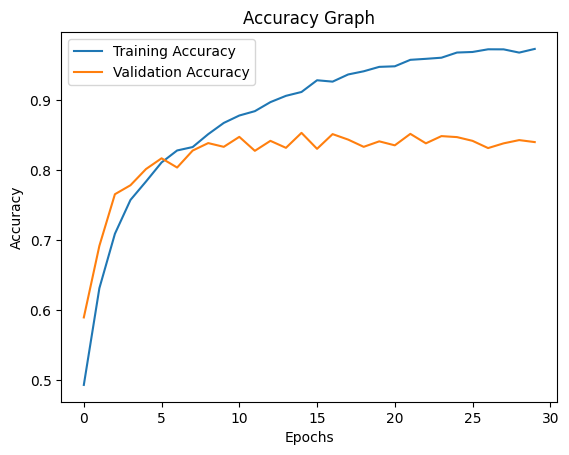

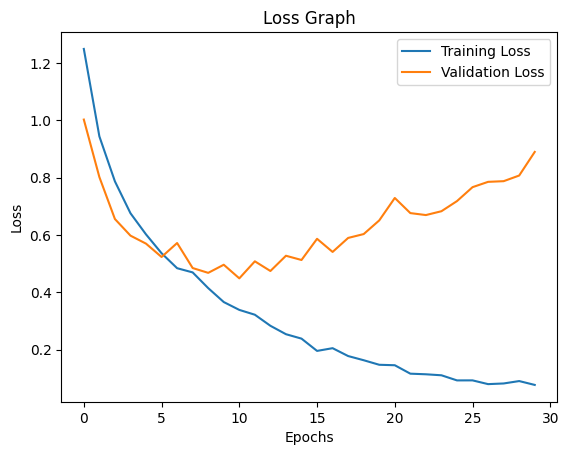

In [15]:
# 10. Accuracy & Loss Graphs
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()